In [1]:
# pip install kagglehub

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import kagglehub

In [3]:
from google.colab import userdata
userdata.get('KAGGLE_API_TOKEN')
from kagglehub import KaggleDatasetAdapter

file_path = "bank_churn_dataset.csv"

bank = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "thuandao/bank-customer-behavior-and-churn-dataset", file_path)
bank.columns

Using Colab cache for faster access to the 'bank-customer-behavior-and-churn-dataset' dataset.


Index(['id', 'full_name', 'credit_sco', 'gender', 'age', 'occupation',
       'balance', 'monthly_ir', 'address', 'origin_province', 'tenure_ye',
       'married', 'nums_card', 'nums_service', 'active_member',
       'last_active_date', 'last_transaction_month', 'created_date', 'exit',
       'customer_segment', 'engagement_score', 'loyalty_level',
       'digital_behavior', 'risk_score', 'risk_segment', 'cluster_group'],
      dtype='object')

In [4]:
bank.info()
bank.select_dtypes(np.number).describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      80000 non-null  int64  
 1   full_name               80000 non-null  object 
 2   credit_sco              80000 non-null  int64  
 3   gender                  80000 non-null  object 
 4   age                     80000 non-null  int64  
 5   occupation              80000 non-null  object 
 6   balance                 80000 non-null  int64  
 7   monthly_ir              80000 non-null  int64  
 8   address                 80000 non-null  object 
 9   origin_province         80000 non-null  object 
 10  tenure_ye               80000 non-null  int64  
 11  married                 80000 non-null  int64  
 12  nums_card               80000 non-null  int64  
 13  nums_service            80000 non-null  int64  
 14  active_member           80000 non-null

,id,credit_sco,age,balance,monthly_ir,tenure_ye,married,nums_card,nums_service,last_transaction_month,engagement_score,risk_score,cluster_group
count,80000.000000,80000.000000,80000.000000,8.000000e+04,8.000000e+04,80000.000000,80000.000000,80000.000000,80000.000000,8.000000e+04,80000.000000,80000.000000,80000.000000
mean,40000.500000,684.321137,49.381862,6.118320e+07,3.778820e+07,1.777250,0.970825,2.634688,3.564425,8.831755e+06,31.725400,0.269260,1.971037
std,23094.155105,51.169733,15.067480,8.868620e+07,3.655107e+07,1.315828,0.694698,1.218556,2.002448,3.378683e+07,23.474862,0.091891,1.040763
min,1.000000,495.000000,20.000000,4.086630e+05,3.000000e+06,0.000000,0.000000,1.000000,1.000000,0.000000e+00,7.000000,0.017300,1.000000
25%,20000.750000,649.000000,38.000000,1.462592e+07,1.400000e+07,1.000000,1.000000,2.000000,2.000000,0.000000e+00,16.000000,0.200400,1.000000
50%,40000.500000,682.000000,47.000000,3.090276e+07,2.300000e+07,2.000000,1.000000,2.000000,3.000000,0.000000e+00,22.000000,0.277400,2.000000
75%,60000.250000,718.000000,58.000000,6.960994e+07,4.700000e+07,3.000000,1.000000,3.000000,5.000000,0.000000e+00,38.000000,0.338900,2.000000
max,80000.000000,800.000000,90.000000,1.000000e+09,2.160000e+08,4.000000,3.000000,5.000000,8.000000,6.000000e+08,100.000000,0.540400,4.000000


In [5]:
bank['created_date'] = pd.to_datetime(bank['created_date'], format = '%d/%m/%Y', errors="coerce")
bank['last_active_date'] = pd.to_datetime(bank['last_active_date'], format = '%d/%m/%Y', errors="coerce")
bank = bank.drop(columns=['id', 'full_name'])
bank.isna().sum()
bank

,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,tenure_ye,married,...,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,0,2,...,91038993,2025-02-27,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,3,1,...,3255569,2021-07-29,False,Mass,63,Gold,mobile,0.2664,Low,2
2,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,4,0,...,0,2021-03-03,False,Priority,36,Silver,offline,0.1343,Low,4
3,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000,Phường 7 (Q7),TP. Hồ Chí Minh,3,0,...,0,2022-02-12,False,Priority,23,Bronze,offline,0.2185,Low,4
4,677,female,77,Giáo viên/Giảng viên,40532432,25000000,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,2,1,...,0,2022-07-24,False,Emerging,23,Bronze,offline,0.2942,Low,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,682,female,38,Nhân viên văn phòng/Công chức,191593897,18000000,Phường Tân Định (Q1),TP. Hồ Chí Minh,3,1,...,0,2021-09-17,False,Affluent,10,Bronze,offline,0.3094,Low,2
79996,710,female,44,Nhân viên văn phòng/Công chức,169955694,29000000,Phường Bến Thành (Q1),Đồng Nai,3,1,...,0,2022-03-29,False,Affluent,22,Bronze,offline,0.2209,Low,2
79997,701,male,62,Kinh doanh/Bán hàng,148475041,31000000,Phường Tân Định (Q1),TP. Hồ Chí Minh,3,1,...,213134296,2022-03-27,False,Emerging,68,Gold,mobile,0.1510,Low,3
79998,619,male,49,Nội trợ/Sinh viên,95040840,12000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,4,0,...,0,2021-03-29,False,Emerging,14,Bronze,offline,0.3804,Low,2


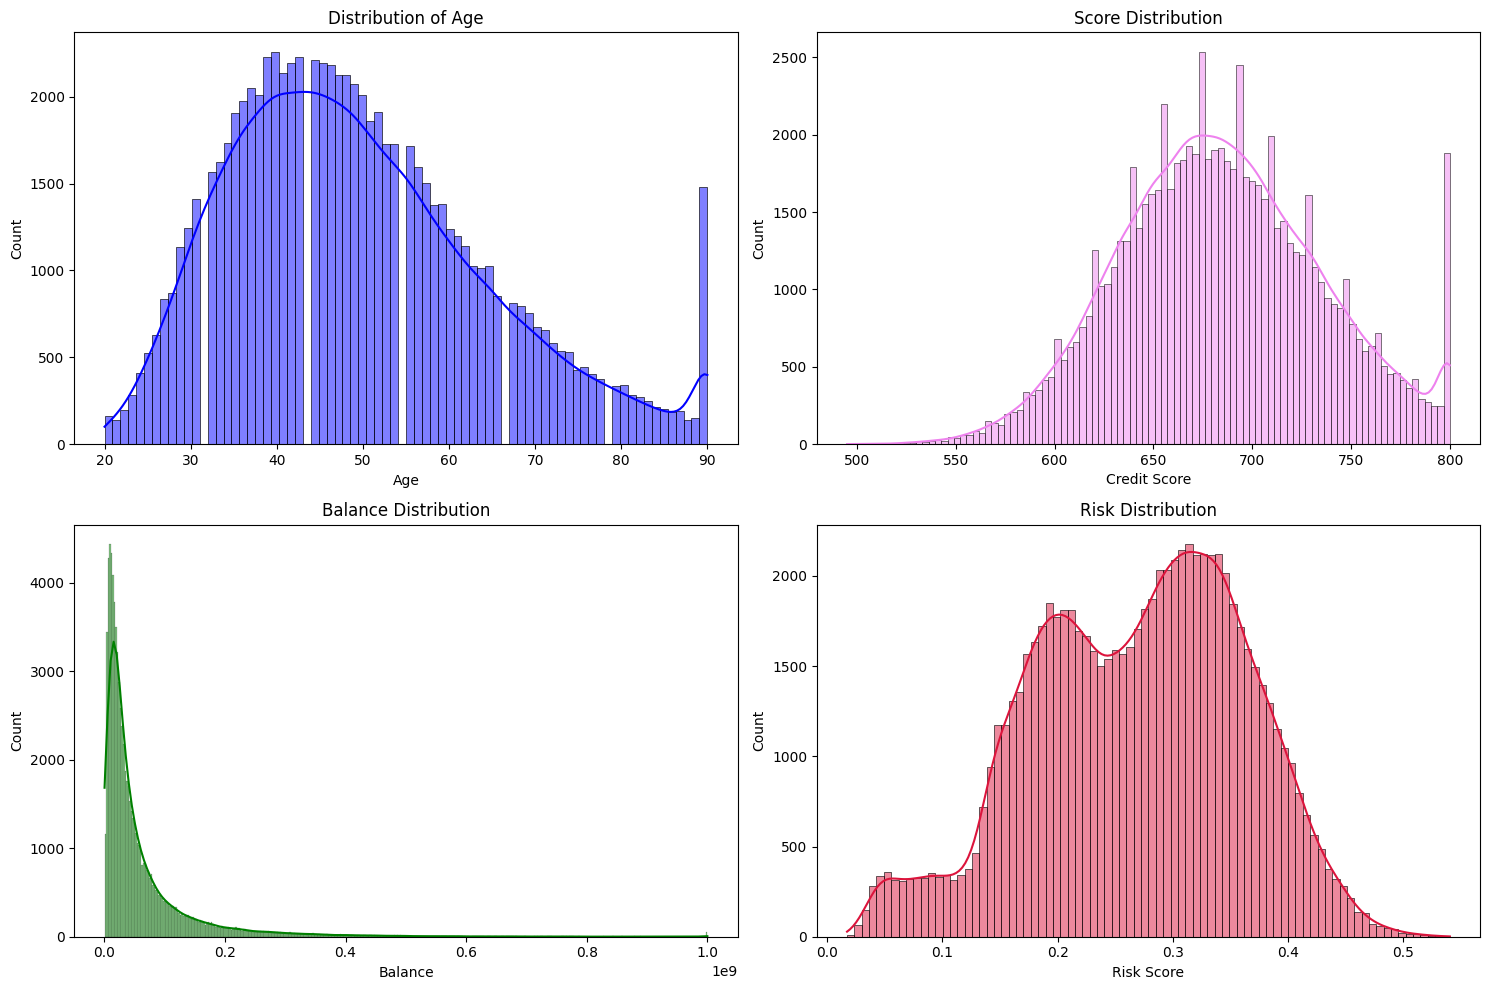

In [6]:
figs, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(bank['age'], kde=True, ax=axes[0,0], color='blue')
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_title("Distribution of Age")


sns.histplot(bank['credit_sco'], kde=True, ax=axes[0,1], color='violet')
axes[0, 1].set_xlabel("Credit Score")
axes[0, 1].set_title("Score Distribution")


sns.histplot(bank['balance'], kde=True, ax=axes[1,0], color='green')
axes[1, 0].set_xlabel("Balance")
axes[1, 0].set_title("Balance Distribution")


sns.histplot(bank['risk_score'], kde=True, ax=axes[1,1], color='crimson')
axes[1, 1].set_xlabel("Risk Score")
axes[1, 1].set_title("Risk Distribution")

plt.tight_layout()
plt.show()

Trend Analysis with Line Plots


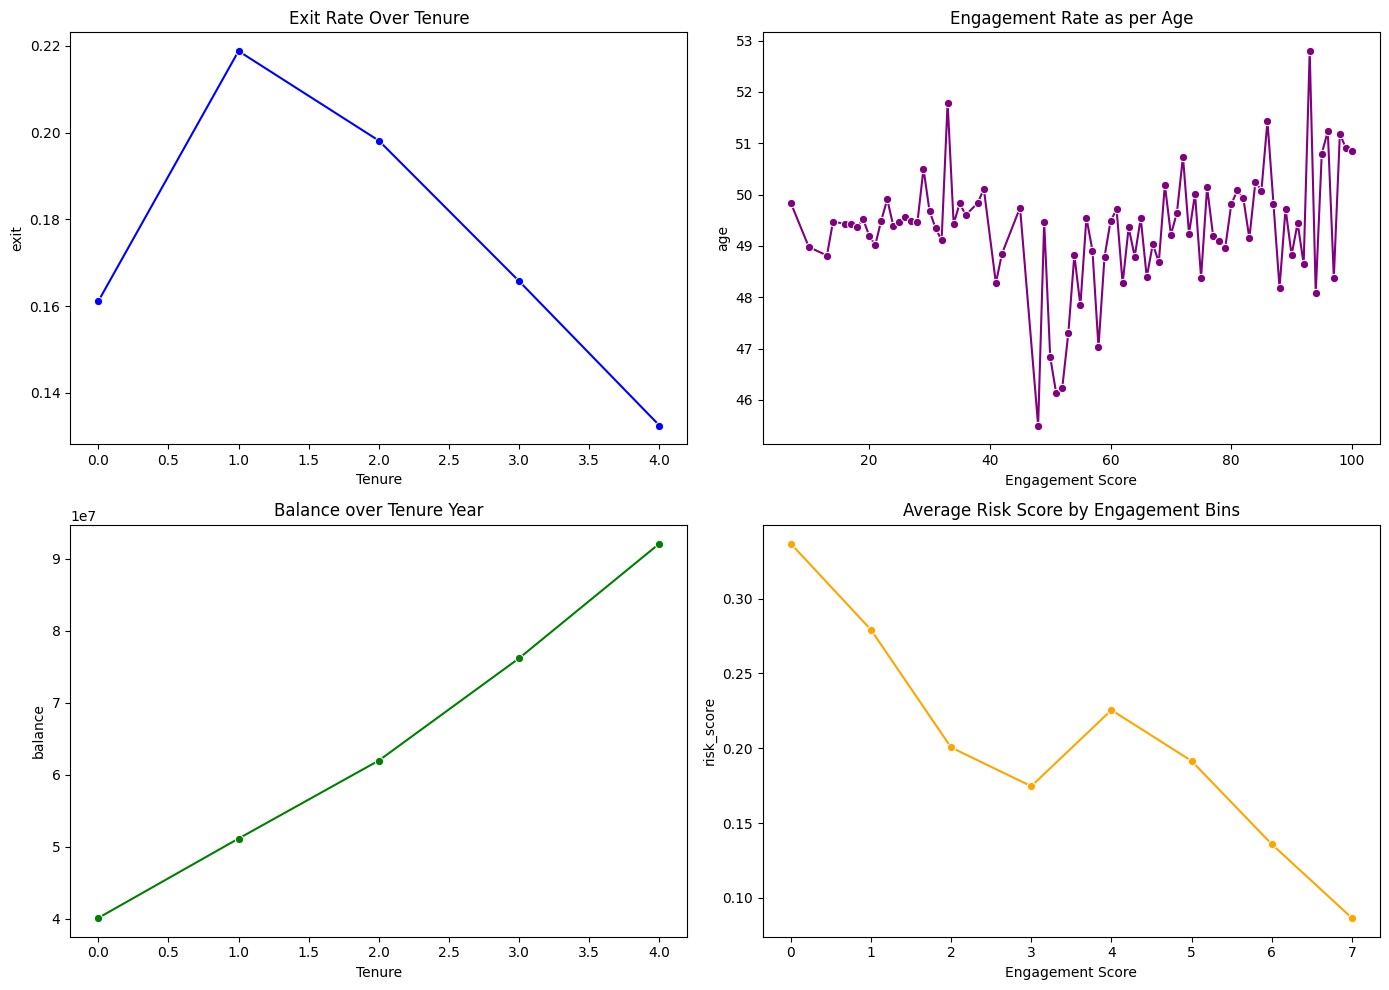

In [7]:
print("Trend Analysis with Line Plots")

figs, axes = plt.subplots(2, 2, figsize=(14, 10))

tenure_data = bank.groupby('tenure_ye')['exit'].mean().reset_index()
sns.lineplot(data=tenure_data, x='tenure_ye', y='exit', ax=axes[0,0], color='blue', marker='o')
axes[0, 0].set_xlabel("Tenure")
axes[0, 0].set_title("Exit Rate Over Tenure")


engagement_rate = bank.groupby('engagement_score')['age'].mean().reset_index()
sns.lineplot(data=engagement_rate, x='engagement_score', y='age', ax=axes[0,1], color='purple', marker='o')
axes[0, 1].set_xlabel("Engagement Score")
axes[0, 1].set_title("Engagement Rate as per Age")


balance_data = bank.groupby('tenure_ye')['balance'].mean().reset_index()
sns.lineplot(data=balance_data, x='tenure_ye', y='balance', ax=axes[1,0], color='green', marker='o')
axes[1, 0].set_xlabel("Tenure")
axes[1, 0].set_title("Balance over Tenure Year")


bank['engagement_bins'] = pd.cut(bank['engagement_score'], bins=8)
risk_rate = bank.groupby('engagement_bins', observed=True)['risk_score'].mean().reset_index()
sns.lineplot(data=risk_rate, x=range(len(risk_rate)), y='risk_score', ax=axes[1,1], color='orange', marker='o')
axes[1, 1].set_xticks(range(len(risk_rate)))
axes[1, 1].set_xlabel("Engagement Score")
axes[1, 1].set_title("Average Risk Score by Engagement Bins")


plt.tight_layout()
plt.show()

Plots to highlight actionable categorical churn drivers


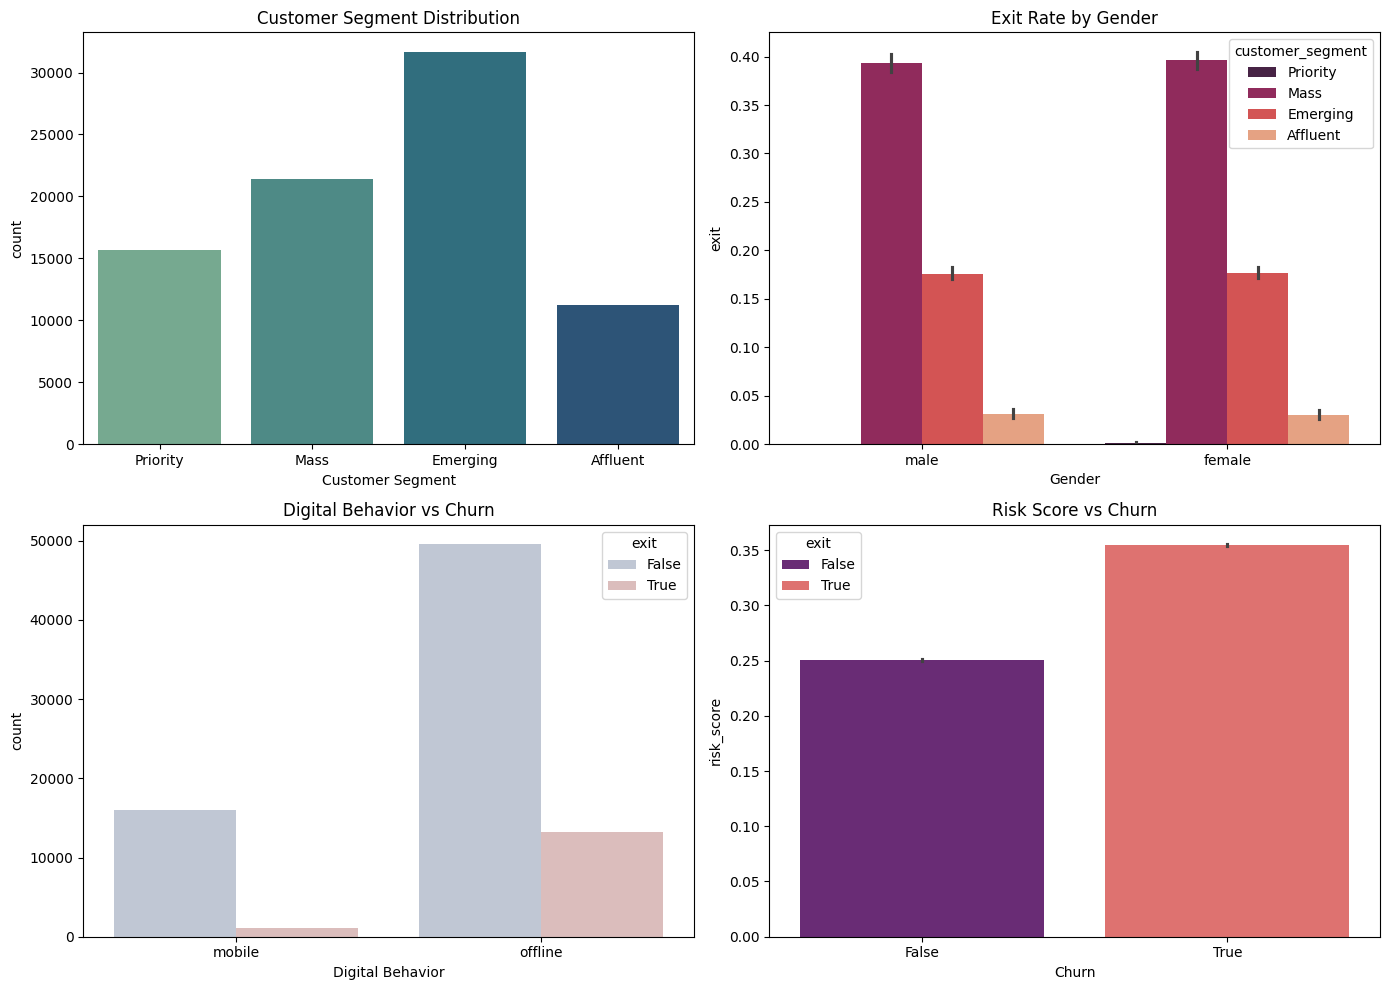

In [8]:
figs, axes = plt.subplots(2 ,2, figsize=(14, 10))

print("Plots to highlight actionable categorical churn drivers")

sns.countplot(data=bank, x='customer_segment', hue='customer_segment', ax=axes[0, 0], palette='crest')
axes[0, 0].set_xlabel("Customer Segment")
axes[0, 0].set_title("Customer Segment Distribution")


sns.barplot(data=bank, x='gender', y='exit', ax=axes[0,1], hue='customer_segment', palette='rocket')
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_title("Exit Rate by Gender")


sns.countplot(data=bank, x='digital_behavior', hue='exit', ax=axes[1, 0], palette='vlag')
axes[1, 0].set_xlabel("Digital Behavior")
axes[1, 0].set_title("Digital Behavior vs Churn")


sns.barplot(data=bank, x='exit', y='risk_score', hue='exit', ax=axes[1, 1], palette='magma')
axes[1, 1].set_xlabel("Churn")
axes[1, 1].set_title("Risk Score vs Churn")


plt.tight_layout()
plt.show()

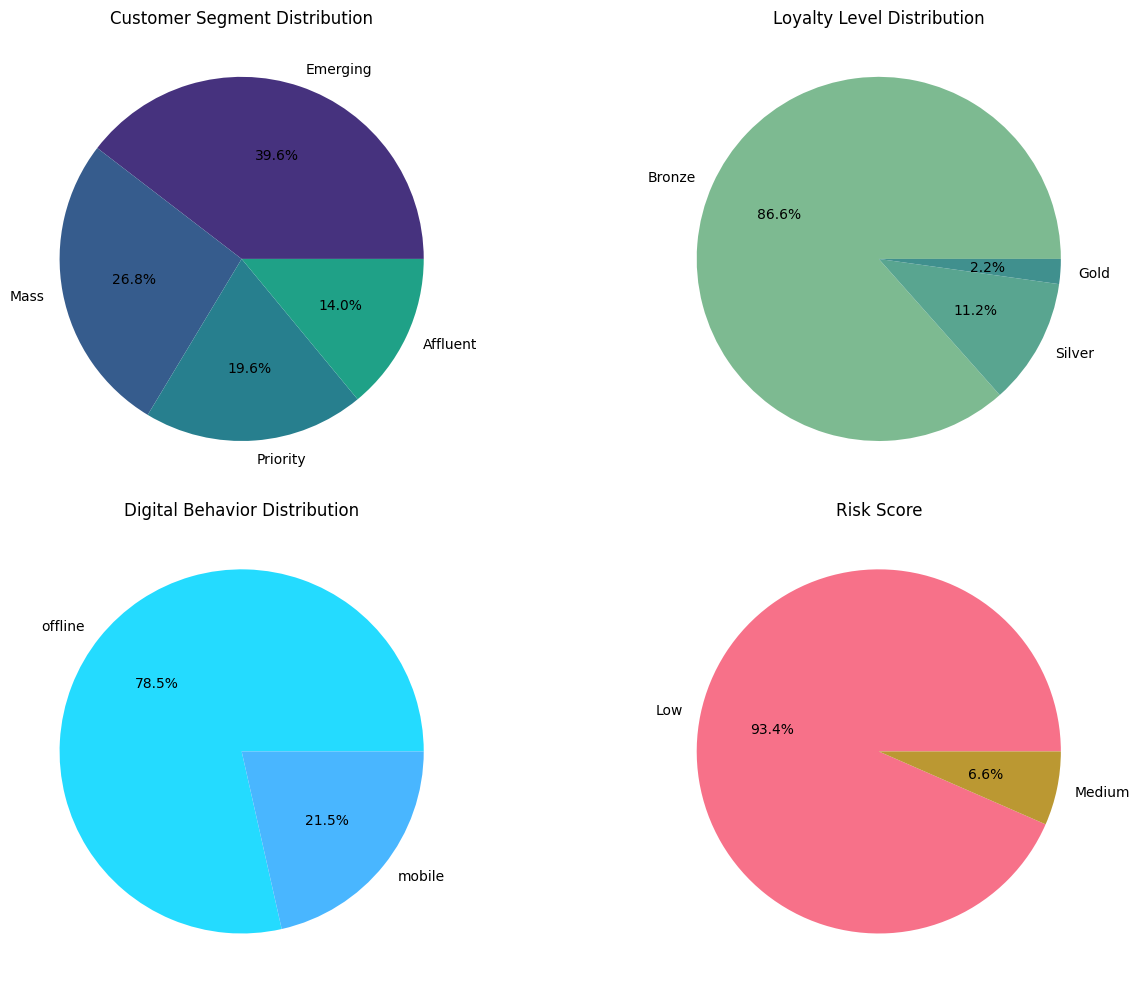

In [9]:
from pandas.core.api import value_counts
figs, axes = plt.subplots(2, 2, figsize=(14, 10))

bank['customer_segment'].value_counts().plot.pie(ax=axes[0, 0], autopct='%1.1f%%', colors = sns.color_palette('viridis'))
axes[0, 0].set_ylabel("")
axes[0, 0].set_title("Customer Segment Distribution")



bank['loyalty_level'].value_counts().plot.pie(ax=axes[0, 1], autopct='%.1f%%', colors = sns.color_palette('crest'))
axes[0, 1].set_ylabel("")
axes[0, 1].set_title("Loyalty Level Distribution")


bank['digital_behavior'].value_counts().plot.pie(ax=axes[1, 0], autopct='%.1f%%', colors = sns.color_palette('cool'))
axes[1, 0].set_ylabel("")
axes[1, 0].set_title("Digital Behavior Distribution")


bank['risk_segment'].value_counts().plot.pie(ax=axes[1, 1], autopct='%.1f%%', colors = sns.color_palette('husl'))
axes[1, 1].set_ylabel("")
axes[1, 1].set_title("Risk Score")


plt.tight_layout()
plt.show()

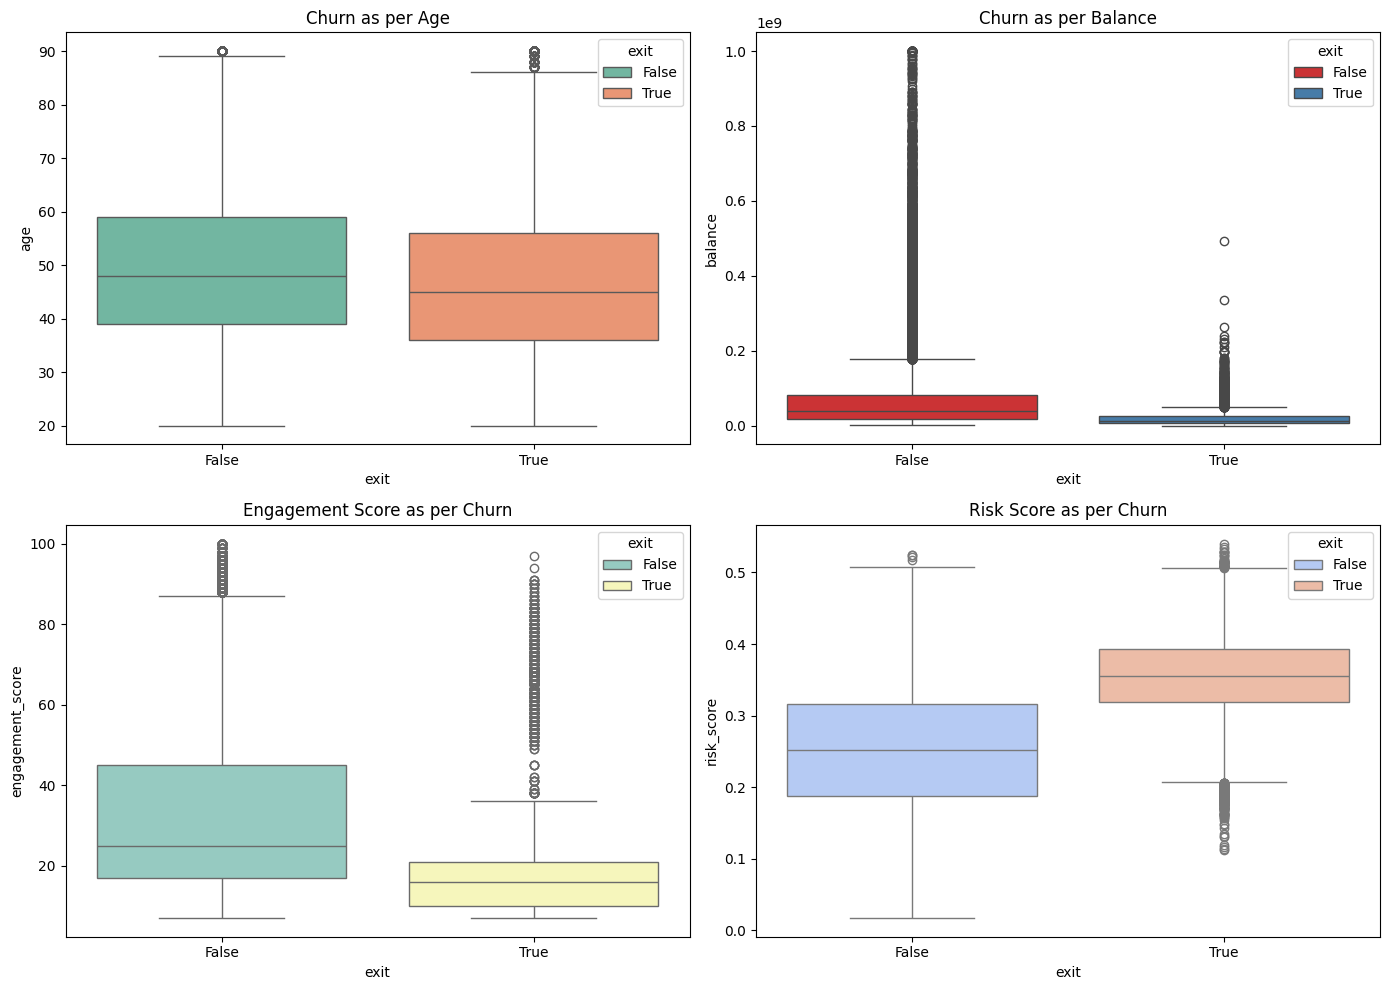

In [10]:
figs, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=bank, x='exit', y='age', hue='exit', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title("Churn as per Age")


sns.boxplot(data=bank, x='exit', y='balance', hue='exit', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title("Churn as per Balance")


sns.boxplot(data=bank, y='engagement_score', x='exit', hue='exit', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title("Engagement Score as per Churn")


sns.boxplot(data=bank, y='risk_score', x='exit', hue='exit', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title("Risk Score as per Churn")

plt.tight_layout()
plt.show()

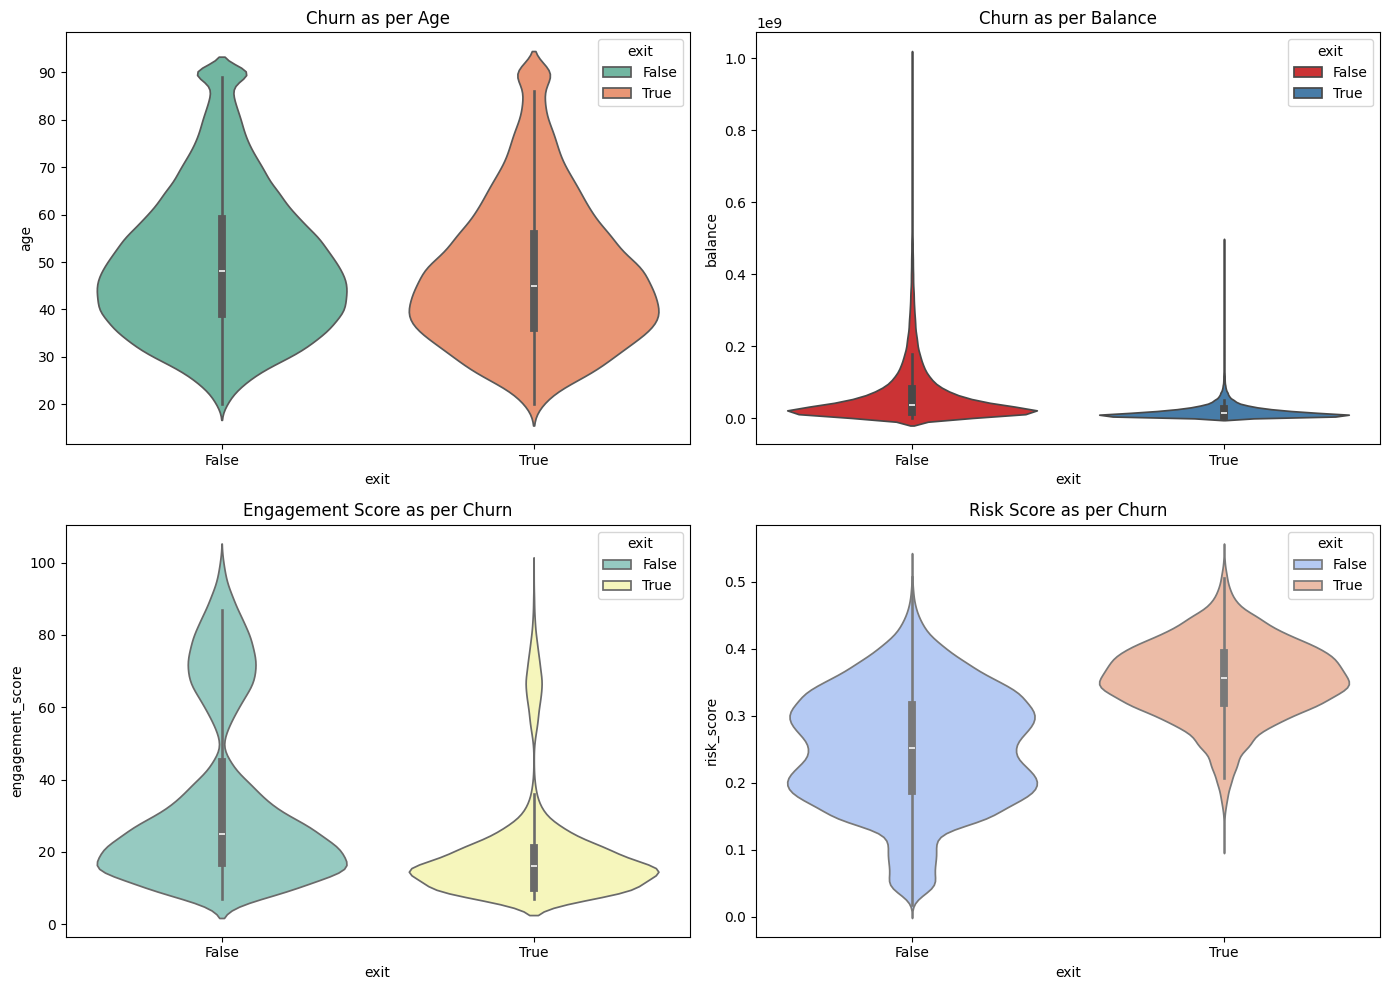

In [11]:
figs, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.violinplot(data=bank, x='exit', y='age', hue='exit', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title("Churn as per Age")


sns.violinplot(data=bank, x='exit', y='balance', hue='exit', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title("Churn as per Balance")


sns.violinplot(data=bank, y='engagement_score', x='exit', hue='exit', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title("Engagement Score as per Churn")


sns.violinplot(data=bank, y='risk_score', x='exit', hue='exit', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title("Risk Score as per Churn")

plt.tight_layout()
plt.show()

In [12]:
bank.select_dtypes(include='object').columns
cat_cols = ['gender', 'occupation', 'address', 'origin_province',
       'customer_segment', 'loyalty_level', 'digital_behavior',
       'risk_segment', 'married']

encoder = LabelEncoder()
for col in cat_cols:
    bank[col] = encoder.fit_transform(bank[col])
bank.head()

,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,tenure_ye,married,...,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group,engagement_bins
0,725,1,55,0,177306004,121000000,4,5,0,2,...,2025-02-27,False,3,90,0,0,0.0359,0,4,"(88.375, 100.0]"
1,689,1,45,8,1927416,5000000,5,8,3,1,...,2021-07-29,False,2,63,1,0,0.2664,0,2,"(53.5, 65.125]"
2,702,0,44,0,304931745,109000000,7,5,4,0,...,2021-03-03,False,3,36,2,1,0.1343,0,4,"(30.25, 41.875]"
3,766,1,44,0,50615501,79000000,3,5,3,0,...,2022-02-12,False,3,23,0,1,0.2185,0,4,"(18.625, 30.25]"
4,677,0,77,1,40532432,25000000,9,5,2,1,...,2022-07-24,False,1,23,0,1,0.2942,0,2,"(18.625, 30.25]"


In [28]:
model = LogisticRegression(max_iter=1000)

scaler = StandardScaler()
bank[bank.select_dtypes(np.number).columns] = scaler.fit_transform(bank[bank.select_dtypes(np.number).columns])

X = bank.drop(columns=['exit'], axis=1).select_dtypes(include=np.number)
y = bank['exit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X, y)

LogisticRegression(max_iter=1000)

In [29]:
prediction = model.predict(X_test)
accuracy = accuracy_score(y_test, prediction)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8410625


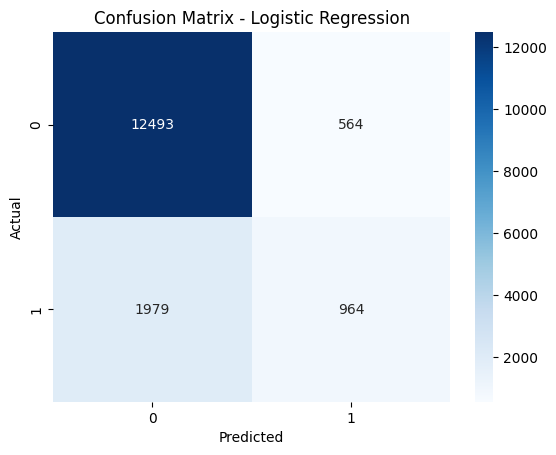

In [24]:
cm = confusion_matrix(y_test, prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

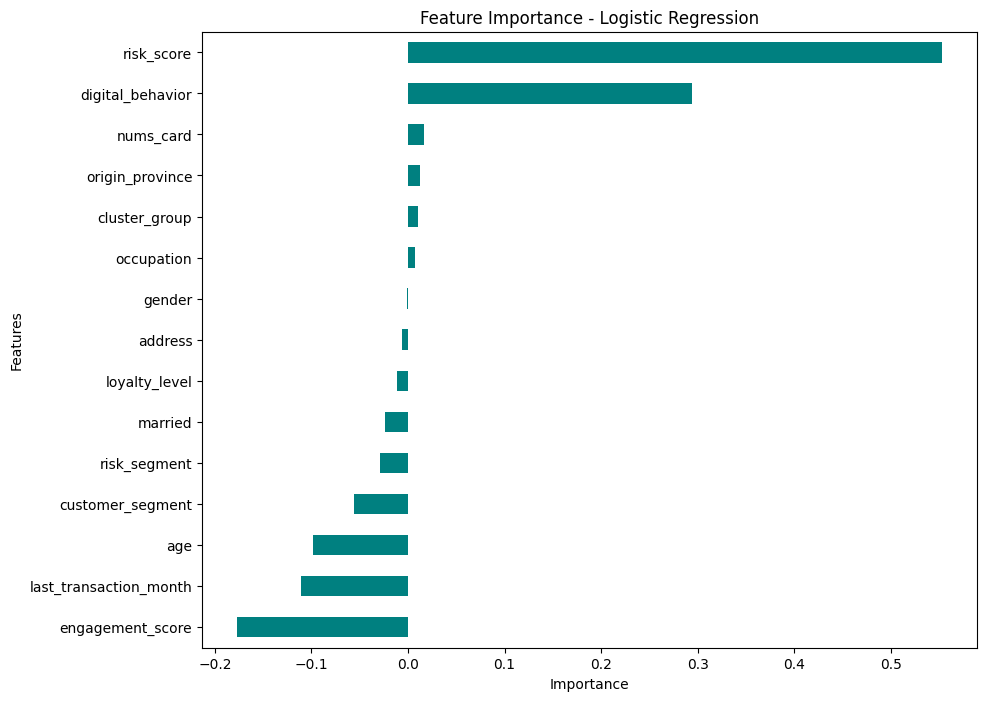

In [27]:
model = RandomForestClassifier()

importances = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=True)
importances.tail(15).plot(kind='barh', figsize=(10,8), color='teal')
plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()